In [1]:
%load_ext water_quality.magics

In [2]:
from water_quality.logs import setup_logging
log = setup_logging()

In [3]:
import xarray as xr
from datacube import Datacube
# Useful later the year to plot for
year = "2023"

# Load the instrument data generated using the prototyping WP1.2 notebooks
wp_12_data_xr = xr.open_dataset("ds_all_final.nc", engine='h5netcdf')
wp_12_data_xr

2026-02-22 19:51:19,253 numexpr.utils [INFO]: NumExpr defaulting to 4 threads.


<xarray.Dataset> Size: 274MB
Dimensions:              (time: 25, y: 170, x: 76, tss_measure: 17,
                          chla_measure: 15)
Coordinates:
  * time                 (time) datetime64[ns] 200B 2000-07-01T23:59:59.99999...
  * y                    (y) float64 1kB 5.731e+04 5.753e+04 ... 9.449e+04
  * x                    (x) float64 608B 3.473e+06 3.474e+06 ... 3.49e+06
  * tss_measure          (tss_measure) <U14 952B 'ndssi_rg_msi' ... 'spm_qiu_...
  * chla_measure         (chla_measure) <U16 960B 'ndci_msi54' ... 'chla_modi...
    spatial_ref          int32 4B ...
Data variables: (12/58)
    wofs_ann_freq        (time, y, x) float32 1MB ...
    wofs_ann_clearcount  (time, y, x) float64 3MB ...
    wofs_ann_wetcount    (time, y, x) float64 3MB ...
    tirs_st_ann_med      (time, y, x) float64 3MB ...
    tirs_st_ann_min      (time, y, x) float64 3MB ...
    tirs_st_ann_max      (time, y, x) float64 3MB ...
    ...                   ...
    ndvi_tm_h            (time, y, x) float32 1MB ...
    ndvi_oli_h           (time, y, x) float64 3MB ...
    ndvi_msi_h           (time, y, x) float64 3MB ...
    hue_tm_h             (time, y, x) float64 3MB ...
    hue_oli_h            (time, y, x) float64 3MB ...
    hue_msi_h            (time, y, x) float64 3MB ...
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

In [4]:
wp_12_data_xr = wp_12_data_xr.rename({"tss": "tsm", "tss_h": "tsm_h", "tss_measure": "tsm_measure"})
wp_12_data_xr

<xarray.Dataset> Size: 274MB
Dimensions:              (time: 25, y: 170, x: 76, tsm_measure: 17,
                          chla_measure: 15)
Coordinates:
  * time                 (time) datetime64[ns] 200B 2000-07-01T23:59:59.99999...
  * y                    (y) float64 1kB 5.731e+04 5.753e+04 ... 9.449e+04
  * x                    (x) float64 608B 3.473e+06 3.474e+06 ... 3.49e+06
  * tsm_measure          (tsm_measure) <U14 952B 'ndssi_rg_msi' ... 'spm_qiu_...
  * chla_measure         (chla_measure) <U16 960B 'ndci_msi54' ... 'chla_modi...
    spatial_ref          int32 4B ...
Data variables: (12/58)
    wofs_ann_freq        (time, y, x) float32 1MB ...
    wofs_ann_clearcount  (time, y, x) float64 3MB ...
    wofs_ann_wetcount    (time, y, x) float64 3MB ...
    tirs_st_ann_med      (time, y, x) float64 3MB ...
    tirs_st_ann_min      (time, y, x) float64 3MB ...
    tirs_st_ann_max      (time, y, x) float64 3MB ...
    ...                   ...
    ndvi_tm_h            (time, y, x) float32 1MB ...
    ndvi_oli_h           (time, y, x) float64 3MB ...
    ndvi_msi_h           (time, y, x) float64 3MB ...
    hue_tm_h             (time, y, x) float64 3MB ...
    hue_oli_h            (time, y, x) float64 3MB ...
    hue_msi_h            (time, y, x) float64 3MB ...
Attributes:
    crs:           EPSG:6933
    grid_mapping:  spatial_ref

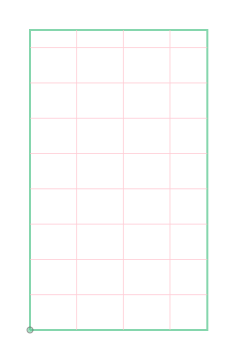

In [5]:
tile_geobox = wp_12_data_xr.odc.geobox
tile_geobox

In [6]:
wq_var_name = "tsm"

In [7]:
bands = wp_12_data_xr[f"{wq_var_name}_measure"].values.tolist()
bands

['ndssi_rg_msi',
 'ndssi_rg_oli',
 'ndssi_rg_tm',
 'ndssi_bnir_oli',
 'ti_yu_oli',
 'ti_yu_tm',
 'tsm_lym_oli',
 'tsm_lym_msi',
 'tsm_lym_tm',
 'tss_grb_msi',
 'tss_grb_oli',
 'tss_grb_tm',
 'tss_gr_msi',
 'tss_gr_oli',
 'tss_gr_tm',
 'spm_qiu_tm',
 'spm_qiu_msi']

In [8]:
import rioxarray

filepath_template = "test/wq_annual/1-0-0/x217/y077/2023--P1Y/wq_annual_x217y077_2023--P1Y_band.tif"
file_list = [filepath_template.replace("band", band) for band in bands]

from pathlib import Path

# Initialize the nested dictionary
wq_ds = {}

# Filter the zip to only include existing files
wq_ds[wq_var_name] = xr.Dataset({
    name: rioxarray.open_rasterio(path).squeeze(drop=True)
    for name, path in zip(bands, file_list)
    if Path(path).exists()  # Only process if file exists
})

wq_ds[wq_var_name]

<xarray.Dataset> Size: 1MB
Dimensions:         (x: 76, y: 170)
Coordinates:
  * x               (x) float64 608B 3.473e+06 3.474e+06 ... 3.49e+06 3.49e+06
  * y               (y) float64 1kB 5.731e+04 5.753e+04 ... 9.427e+04 9.449e+04
    spatial_ref     int64 8B 0
Data variables:
    ndssi_rg_msi    (y, x) float64 103kB ...
    ndssi_rg_oli    (y, x) float64 103kB ...
    ndssi_bnir_oli  (y, x) float64 103kB ...
    ti_yu_oli       (y, x) float64 103kB ...
    tsm_lym_oli     (y, x) float64 103kB ...
    tsm_lym_msi     (y, x) float64 103kB ...
    tss_grb_msi     (y, x) float64 103kB ...
    tss_grb_oli     (y, x) float64 103kB ...
    tss_gr_msi      (y, x) float64 103kB ...
    tss_gr_oli      (y, x) float64 103kB ...
    spm_qiu_msi     (y, x) float64 103kB ...

In [9]:
# new bands list

bands = list(wq_ds[wq_var_name].data_vars)
bands

['ndssi_rg_msi',
 'ndssi_rg_oli',
 'ndssi_bnir_oli',
 'ti_yu_oli',
 'tsm_lym_oli',
 'tsm_lym_msi',
 'tss_grb_msi',
 'tss_grb_oli',
 'tss_gr_msi',
 'tss_gr_oli',
 'spm_qiu_msi']

In [10]:
def required_counts(da_):
    valid_pixels = da_.count().item()
    total_pixels = da_.size
    return f"{valid_pixels} valid_pixels \n {total_pixels} total pixels"

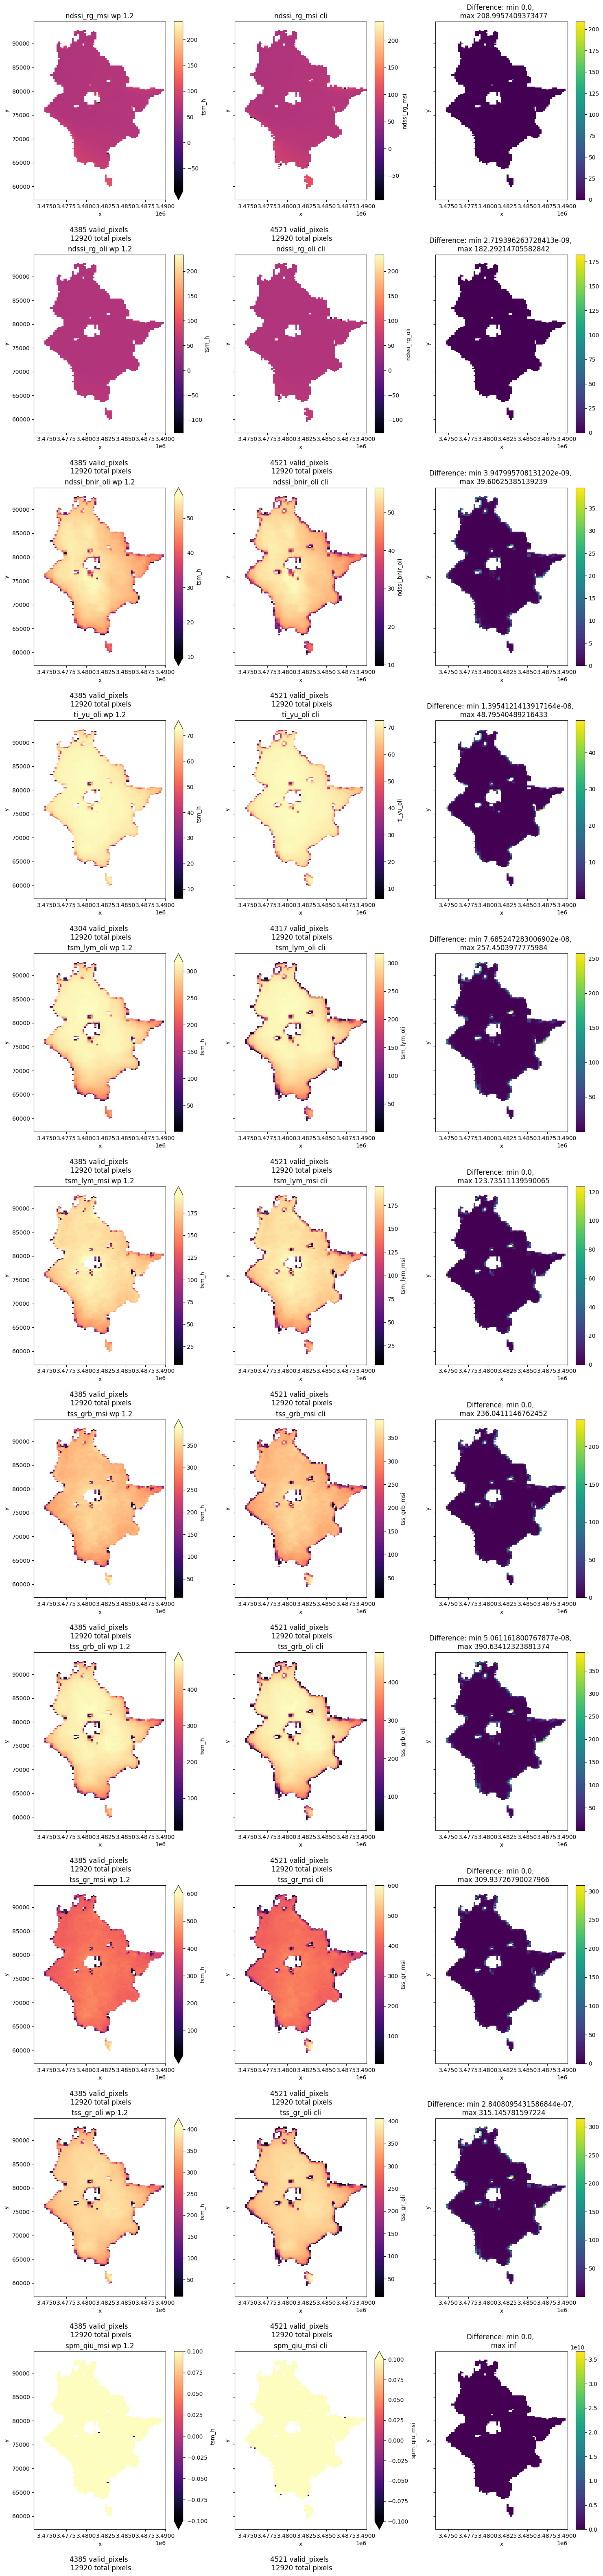

In [11]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np


n_variables = len(bands)
n_plots_per_variable = 3
ncols = n_plots_per_variable  # columns for ref, da, and diff plots
nrows = n_variables           # rows for each variable

fig, axs = plt.subplots(nrows, ncols, sharey=True, figsize=(15, 6 * nrows))

cmap = "magma"

for var in bands:
    i = bands.index(var)
    ref_da = wp_12_data_xr[f"{wq_var_name}_h"].sel({f"{wq_var_name}_measure":var}).sel(time=year)
    da = wq_ds[wq_var_name][var]
    diff = np.abs(ref_da - da)
    
    min_diff = diff.min().item()
    max_diff = diff.max().item() 

    # --- Plotting within the loop, using the row index 'i' ---
    # Plot 'ref_da' on the first column of the current row
    norm = mcolors.Normalize(vmin=da.min(), vmax=da.max())

    ref_da.plot( cmap=cmap, norm=norm, ax=axs[i, 0])
    axs[i, 0].text(0.5, -0.15, required_counts(ref_da), 
                transform=axs[i, 0].transAxes, 
                ha='center', va='top', fontsize=12)
    axs[i, 0].set_title(f"{var} wp 1.2")

    # Plot 'da' on the second column of the current row
    da.plot( cmap=cmap, norm=norm, ax=axs[i, 1])
    axs[i, 1].text(0.5, -0.15, required_counts(da), 
                transform=axs[i, 1].transAxes, 
                ha='center', va='top', fontsize=12)
    axs[i, 1].set_title(f"{var} cli")

    # Plot 'diff' on the third column of the current row
    diff.plot(ax=axs[i, 2])
    axs[i, 2].set_title(f"Difference: min {min_diff}, \n  max {max_diff}")


        
plt.tight_layout(rect=[0, 0, 1, 0.96]) # rect argument is used to make space for suptitle
plt.savefig(f'{wq_var_name}_not_stacked_comparison.png', dpi=200)

# Optional: Display the final plot
plt.show()